In [1]:
!python --version


Python 3.11.11


In [29]:
import numpy as np
import librosa as lb
import matplotlib.pyplot as plt
import soundfile as sf
from pathlib import Path
from IPython.display import Audio
from tqdm import tqdm

In [3]:
noisy_train_dir = Path('data/archive/noisy_trainset_28spk_wav')

In [4]:
clean_train_dir = Path('data/archive/clean_trainset_28spk_wav')

In [5]:
noisy_count = len(list(noisy_train_dir.glob('*.wav')))
print(noisy_count)

11572


In [6]:
clean_count = len(list(clean_train_dir.glob('*.wav')))
print(clean_count)

11572


In [7]:
noisy_files = sorted(noisy_train_dir.glob('*.wav'))
print(noisy_files[1])

data/archive/noisy_trainset_28spk_wav/p226_002.wav


In [8]:
clean_files = sorted(clean_train_dir.glob('*.wav'))
print(clean_files[1])

data/archive/clean_trainset_28spk_wav/p226_002.wav


In [9]:
y, sr  = lb.load(noisy_files[0],sr=None)
print(y)
print(sr)

[-0.00253296 -0.00396729 -0.00491333 ...  0.00640869  0.00558472
  0.0067749 ]
16000


In [10]:
y, sr  = lb.load(clean_files[0],sr=None)
print(y)
print(sr)

[-0.00259399 -0.00405884 -0.00488281 ... -0.00210571 -0.00158691
 -0.00076294]
16000


In [11]:
audio_path = (noisy_files[0])
audio = Audio(audio_path)
audio

In [12]:

file_1, sr = lb.load(clean_files[0],sr=None)
file_2, r = lb.load(noisy_files[0],sr=None)

if len(file_1) == len(file_2) :
    print("same size")
else :
    print("the size is not the same")

same size


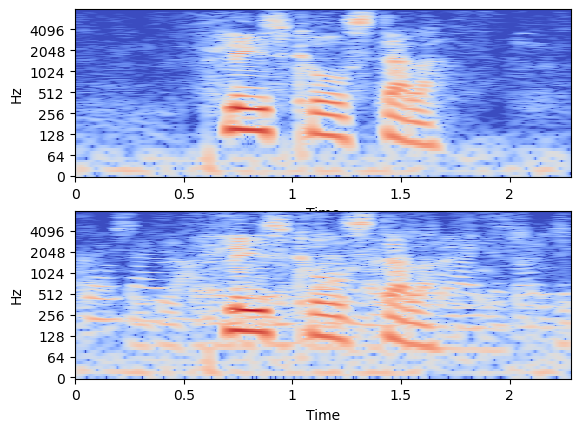

In [24]:
plt.subplot(2,1,1)
hop_length = 64
D1 = lb.amplitude_to_db(np.abs(lb.stft(file_1, hop_length=hop_length)))
lb.display.specshow(D1, sr=16000, x_axis='time', y_axis='log',hop_length=hop_length )
plt.subplot(2,1,2)

D2 = lb.amplitude_to_db(np.abs(lb.stft(file_2,hop_length=hop_length)))
lb.display.specshow(D2, sr=16000, x_axis='time', y_axis='log',hop_length=hop_length )


In [37]:
lenght = []

for file in tqdm(noisy_files, total=len(noisy_files)) :
    y, sr = lb.load(file)
    L = len(y)
    lenght.append(L)

print(max(lenght)/16000, min(lenght)/16000)

100%|███████████████████████████████████| 11572/11572 [00:11<00:00, 1038.60it/s]

20.8263125 1.5054375


In [48]:
noisy_chunks = []
for file in tqdm(noisy_files, total=len(noisy_files)):
    y, sr = lb.load(file, sr=None)
    y = y[:(len(y)//sr) * sr]
    C = np.split(y, len(y)//sr)
    noisy_chunks.append(C)

100%|███████████████████████████████████| 11572/11572 [00:01<00:00, 7471.97it/s]


In [49]:
len(noisy_chunks[0][0])

16000

In [52]:
clean_chunks = []
for file in tqdm(clean_files, total=len(clean_files)):
    y, sr = lb.load(file, sr=None)
    y = y[:(len(y)//sr) * sr]
    C = np.split(y, len(y)//sr)
    clean_chunks.append(C)

100%|███████████████████████████████████| 11572/11572 [00:03<00:00, 2975.86it/s]


In [53]:
len(clean_chunks[0][0])

16000

In [59]:
clean_chunks_list = []
for y_c in tqdm(clean_chunks, total=len(clean_chunks)):
    for y_d in y_c :
        clean_chunks_list.append(y_d)

100%|█████████████████████████████████| 11572/11572 [00:00<00:00, 765897.97it/s]


In [62]:
clean_chunks_list[0]

array([-0.00259399, -0.00405884, -0.00488281, ..., -0.00128174,
        0.00036621,  0.00363159], shape=(16000,), dtype=float32)

In [63]:
noisy_chunks_list = []
for y_c in tqdm(noisy_chunks, total=len(clean_chunks)):
    for y_d in y_c :
        noisy_chunks_list.append(y_d)

100%|█████████████████████████████████| 11572/11572 [00:00<00:00, 591043.42it/s]


In [64]:
noisy_chunks_list[0]

array([-0.00253296, -0.00396729, -0.00491333, ..., -0.00604248,
       -0.00479126, -0.00250244], shape=(16000,), dtype=float32)